Olá, **Luísa Ayres**!

O meu nome é **César Malaguti** e sou o revisor do seu projeto. Quando identificar um erro pela primeira vez, apenas vou apontá-lo para que você mesmo possa encontrá-lo e corrigi-lo. Ao longo do notebook farei observações sobre as suas análises, sempre com o objetivo de te preparar para atuar como **Analista ou Cientista de Dados** no mercado. **Por favor, não mova, modifique ou exclua meus comentários.**

Você vai encontrar meus comentários em caixas coloridas:
<div class="alert alert-block alert-success"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Sucesso.</div>
<div class="alert alert-block alert-warning"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Atenção (sugestão).</div>
<div class="alert alert-block alert-danger"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Precisa de correção.</div>

Você pode me responder usando:
<div class="alert alert-block alert-info"><b>Resposta do Aluno.</b> <a class="tocSkip"></a></div>


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

<b>Comentário geral:</b> Luísa, parabéns, **projeto APROVADO!** O projeto cobre as seis seções e faz o que este trabalho de fato cobra: **auditar o experimento antes de confiar no resultado**.

Você aplicou três cuidados que a maioria deixa passar:

**1. A janela de 14 dias.** A especificação define que só contam os eventos dos primeiros 14 dias após o cadastro de cada usuário, e você aplicou o recorte de verdade, criando o `test_events_14d`. Muita gente cita a regra na introdução e depois analisa tudo.

**2. Os 441 usuários presentes nos dois grupos**, identificados e removidos. Quem viu as duas versões não pertence a nenhum lado, e mantê-lo aproxima os grupos artificialmente.

**3. A correção de Bonferroni**, aplicada porque você fez dois testes e quis controlar o risco de falso positivo.

E o encerramento é o formato certo: uma **tabela** reunindo etapa, aumento observado, meta de 10% e p-value, seguida das conclusões. Ótimo trabalho!
</div>

**1. Objetivos do estudo**

O objetivo principal é avaliar se a introdução de um sistema de recomendação aprimorado aumenta a conversão dos usuários do grupo B em comparação com o grupo A.

As três etapas do funil que serão analisadas são:

**product_page → product_cart → purchase**

O resultado esperado é um aumento de pelo menos 10% em cada etapa do funil para o grupo B em relação ao grupo A, considerando usuários acompanhados por até 14 dias após o cadastro.

Além disso, precisamos verificar se o teste foi realizado corretamente, considerando:

- Se há problemas nos dados, como tipo incorreto de dados, duplicidades ou valores ausentes;
- Se os participantes pertencem ao público-alvo;
- Se a divisão entre os grupos A e B está adequada;
- Se as datas do teste estão corretas;
- Se existem usuários participando de mais de um teste;
- Se as diferenças de conversão entre os grupos são estatisticamente significativas.

**Hipóteses**

Para cada etapa do funil analisada, serão comparadas as taxas de conversão dos grupos A e B.

**H0 (hipótese nula):** As taxas de conversão dos grupos A e B são iguais.

**H1 (hipótese alternativa):** As taxas de conversão dos grupos A e B são diferentes.

Como o objetivo do experimento é obter um aumento na conversão do grupo B, após verificar a significância estatística da diferença, será analisada também a direção do efeito e se o aumento observado atinge o mínimo esperado de 10%.

Assim, serão avaliadas as seguintes conversões:

**product_page → product_cart**  
**product_cart → purchase**

Para que o resultado seja considerado favorável ao novo sistema de recomendação, **o grupo B deverá apresentar aumento de pelo menos 10% em relação ao grupo A**, além de uma diferença estatisticamente significativa no teste Z.

**2. Limitações do desenho experimental que possam influenciar os resultados do estudo**

Alguns pontos que devemos investigar:

- O teste deveria ter aproximadamente 6.000 participantes, então precisamos verificar quantos realmente participaram;
- Apenas 15% dos novos usuários da União Européia deveriam participar;
- O período de recrutamento foi de 07/12/2020 a 21/12/2020, enquanto o teste terminou em 01/01/2021;
- O acompanhamento esperado é de até 14 dias após o cadastro, portanto usuários cadastrados perto de 21/12 podem não ter tido os 14 dias completos de observação;
- Precisamos verificar se existem usuários em mais de um grupo;
- Precisamos verificar se existem usuários participantes de outros testes que possam sofrer influência de outras alterações;
- A distribuição entre A e B precisa ser equilibrada;
- O período de Natal e Ano Novo pode alterar o comportamento de compra e introduzir um efeito sazonal;

Essas limitações não significam necessariamente que o teste seja inválido, mas podem reduzir a confiabilidade da comparação.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Boa decisão de estrutura: colocar as **limitações do desenho** logo no início, como uma seção própria, antes de qualquer análise.

Isso muda a natureza do trabalho. Um relatório que começa listando o que pode dar errado no experimento sinaliza que os resultados serão lidos com a cautela adequada. Já um relatório que apresenta o p-value primeiro e as ressalvas no rodapé convida o leitor a ignorar as ressalvas.
</div>

**3. Diagnóstico inicial dos dados**

Começamos importando as bibliotecas e carregando os 4 arquivos.

In [1]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st

In [2]:
# lendo o conjunto de dados dos datasets
marketing_events = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

Em seguida, visualizaremos as primeiras linhas dos datasets e verificaremos o número de linhas e de colunas em cada um.

In [3]:
# Imprimindo as 5 primeiras linhas do dataset marketing_events
marketing_events.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [4]:
# Imprimindo as 5 primeiras linhas do dataset new_users
new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [5]:
# Imprimindo as 5 primeiras linhas do dataset events
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [6]:
# Imprimindo as 5 primeiras linhas do dataset participants
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [7]:
# Mostrando o número de linhas e colunas do dataset marketing_events
marketing_events.shape

(14, 4)

In [8]:
# Mostrando o número de linhas e colunas do dataset new_users
new_users.shape

(58703, 4)

In [9]:
# Mostrando o número de linhas e colunas do dataset events
events.shape

(423761, 4)

In [10]:
# Mostrando o número de linhas e colunas do dataset participants
participants.shape

(14525, 3)

Será necessário imprimir as informações dos datasets para verificar os tipos de dados, inconsistências e valores ausentes.

In [11]:
# Imprimindo as informações do dataset marketing_events e determinando o tamanho exato dos dados
marketing_events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 4.0 KB


In [12]:
# Imprimindo as informações do dataset new_users e determinando o tamanho exato dos dados
new_users.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 14.7 MB


In [13]:
# Imprimindo as informações do dataset events e determinando o tamanho exato dos dados
events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 89.9 MB


In [14]:
# Imprimindo as informações do dataset participants e determinando o tamanho exato dos dados
participants.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 2.9 MB


No dataset marketing_events não foram encontrados valores ausentes. Em relação aos tipos de dados, será necessário converter as colunas start_dt e finish_dt de object para datetime.

In [15]:
# Convertendo as colunas start_dt e finish_dt do dataset marketing_events de object para datetime
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'], format="%Y-%m-%d")
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'], format="%Y-%m-%d")
marketing_events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 2.4 KB


Será verificado o número de valores únicos da coluna regions.

In [16]:
# Encontrando o número de valores únicos na coluna device do dataset new_users e como elas são distribuídas
marketing_events['regions'].value_counts()

APAC                        4
EU, CIS, APAC, N.America    3
CIS                         2
EU, CIS, APAC               2
EU, N.America               2
N.America                   1
Name: regions, dtype: int64

No dataset new_users também não foram encontrados valores ausentes. Em relação aos tipos de dados, será necessário converter a coluna first_date para datetime.

In [17]:
# Convertendo a coluna first_date do dataset new_users de object para datetime
new_users['first_date'] = pd.to_datetime(new_users['first_date'], format="%Y-%m-%d")
new_users.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 11.4 MB


Será verificado o número de valores únicos da coluna regions e device.

In [18]:
# Encontrando o número de valores únicos na coluna region do dataset new_users e como elas são distribuídas
new_users['region'].value_counts()

EU           43396
N.America     9051
CIS           3130
APAC          3126
Name: region, dtype: int64

Como há apenas 4 categorias, o tipo de dado da coluna region do dataset new_users será transformado para category.

In [19]:
# Convertendo a coluna device do dataset new_users de object para category
new_users['region'] = new_users['region'].astype('category')
new_users.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  category      
 3   device      58703 non-null  object        
dtypes: category(1), datetime64[ns](1), object(2)
memory usage: 8.1 MB


Podemos verificar que após a conversão do tipo de dado de object para category, a memória usada reduziu de 11.4 MB para 8.1 MB.

In [20]:
# Encontrando o número de valores únicos na coluna device do dataset new_users e como elas são distribuídas
new_users['device'].value_counts()

Android    26159
PC         14845
iPhone     11902
Mac         5797
Name: device, dtype: int64

Como há apenas 4 categorias, o tipo de dado da coluna device do dataset new_users será transformado para category.

In [21]:
# Convertendo a coluna device do dataset new_users de object para category
new_users['device'] = new_users['device'].astype('category')
new_users.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  category      
 3   device      58703 non-null  category      
dtypes: category(2), datetime64[ns](1), object(1)
memory usage: 4.6 MB


Podemos verificar que após a conversão do tipo de dado de object para category, a memória usada reduziu de 8.1 MB para 4.6 MB.

No dataset events foram encontrados valores ausentes na coluna details, veremos a quantidade posteriormente. Em relação aos tipos de dados, será necessário converter a coluna event_dt para datetime.

In [22]:
# Convertendo a coluna event_dt do dataset events de object para datetime
events['event_dt'] = pd.to_datetime(events['event_dt'], format="%Y-%m-%d %H:%M:%S")
events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 62.4 MB


Será verificado o número de valores únicos da coluna event_name.

In [23]:
# Encontrando o número de valores únicos na coluna event_name do dataset events e como elas são distribuídas
events['event_name'].value_counts()

login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64

Como há apenas 4 categorias, o tipo de dado da coluna event_name do dataset events será transformado para category.

In [24]:
# Convertendo a coluna event_name do dataset events de object para category
events['event_name'] = events['event_name'].astype('category')
events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  category      
 3   details     60314 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), object(1)
memory usage: 36.4 MB


Podemos verificar que após a conversão do tipo de dado de object para category, a memória usada reduziu de 62.4 MB para 36.4 MB.

No dataset participants não foram encontrados valores ausentes. Será verificado o número de valores únicos das colunas group e ab_test.

In [25]:
# Encontrando o número de valores únicos na coluna group do dataset participants e como elas são distribuídas
participants['group'].value_counts()

A    8214
B    6311
Name: group, dtype: int64

Como há apenas 2 categorias, o tipo de dado da coluna group do dataset participants será transformado para category.

In [26]:
# Convertendo a coluna group do dataset participants de object para category
participants['group'] = participants['group'].astype('category')
participants.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   user_id  14525 non-null  object  
 1   group    14525 non-null  category
 2   ab_test  14525 non-null  object  
dtypes: category(1), object(2)
memory usage: 2.1 MB


Podemos verificar que após a conversão do tipo de dado de object para category, a memória usada reduziu de 2.9 MB para 2.1 MB.

In [27]:
# Encontrando o número de valores únicos na coluna ab_test do dataset participants e como elas são distribuídas
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

Como há apenas 2 categorias, o tipo de dado da coluna ab_test do dataset participants será transformado para category.

In [28]:
# Convertendo a coluna ab_test do dataset participants de object para category
participants['ab_test'] = participants['ab_test'].astype('category')
participants.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   user_id  14525 non-null  object  
 1   group    14525 non-null  category
 2   ab_test  14525 non-null  category
dtypes: category(2), object(1)
memory usage: 1.0 MB


Podemos verificar que após a conversão do tipo de dado de object para category, a memória usada reduziu de 2.1 MB para 1.0 MB.

In [29]:
# Confirmando que não há valores ausentes no dataset marketing_events
marketing_events.isna().sum()

name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

In [30]:
# Confirmando que não há valores ausentes no dataset new_users
new_users.isna().sum()

user_id       0
first_date    0
region        0
device        0
dtype: int64

In [31]:
# Confirmando que não há valores ausentes no dataset participants
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [32]:
# Verificando a quantidade de valores ausentes no dataset events
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Foram encontrados 363447 valores ausentes na coluna details. Um ponto importante é não excluir automaticamente os valores ausentes. A coluna details pode apresentar valores ausentes porque nem todos os eventos possuem informações adicionais. Isso pode ser normal.

Será necessário verificar duplicados nos datasets.

In [33]:
# Verificando se há linhas completamente duplicadas no dataset marketing_events
marketing_events.duplicated().sum()

0

Não foram encontrados duplicados no dataset marketing_events.

In [34]:
# Verificando se há linhas completamente duplicadas no dataset new_users
new_users.duplicated().sum()

0

Não foram encontrados duplicados no dataset new_users.

In [35]:
# Verificando se há linhas completamente duplicadas no dataset events
events.duplicated().sum()

0

Não foram encontrados duplicados no dataset events.

In [36]:
# Verificando se há linhas completamente duplicadas no dataset participants
participants.duplicated().sum()

0

Não foram encontrados duplicados no dataset participants.

**4. Análise exploratória dos dados (EDA)**

Anteriormente, com value_counts, foi observada uma distribuição desigual entre os grupos A e B, com 8.214 participantes no grupo A e 6.311 no grupo B. Essa diferença deve ser investigada, pois uma alocação desequilibrada pode afetar a precisão das estimativas e a comparação das taxas de conversão. Além disso, o número total de participantes é superior aos 6.000 usuários previstos no planejamento do experimento. Portanto, antes da análise estatística, é necessário verificar se esses usuários pertencem exclusivamente ao teste recommender_system_test, eliminar os usuários presentes simultaneamente nos dois grupos e confirmar o número final de participantes.  
Anteriormente, foram encontrados 10850 valores únicos em interface_eu_test e 3675 valores únicos em recommender_system_test. Será necessária uma análise de recommender_system_test.

In [37]:
# Filtrando o DataFrame participants para manter apenas os participantes que pertencem ao teste recommender_system_test
recommender_participants = participants[participants['ab_test'] == 'recommender_system_test'].copy()

In [38]:
# Verificando a quantidade de usuários em cada grupo 
recommender_participants['group'].value_counts()

A    2747
B     928
Name: group, dtype: int64

In [39]:
# Calculando a proporção entre os grupos
recommender_participants['group'].value_counts(normalize=True)

A    0.747483
B    0.252517
Name: group, dtype: float64

Foram encontrados 2747 valores únicos no grupo A em recommender_system_test e 928 valores únicos no grupo B. Esses números revelam uma desproporção entre os grupos, sendo de 74.75% no grupo A e 25.25% no grupo B.

In [40]:
# Verificando se há usuários presentes nos dois grupos no dataset participants
users_both_groups = (participants.groupby('user_id')['group'].nunique())
users_both_groups = users_both_groups[users_both_groups > 1].index
len(users_both_groups)

441

Há 441 usuários presentes nos dois grupos, o que é um problema grave para a análise, pois um mesmo usuário estaria sendo utilizado simultaneamente como controle e teste. Nesse caso, será necessário excluir os 441 usuários, já que em um teste A/B os grupos precisam ser independentes. A permanência desses usuários poderia contaminar as métricas de conversão e comprometer a comparação entre os grupos.

In [41]:
# Removendo os 441 usuários presentes nos 2 grupos
participants_clean = participants[~participants['user_id'].isin(users_both_groups)].copy()
participants_clean.groupby('user_id')['group'].nunique().max()

1

In [42]:
# Verificando os grupos após a remoção
participants_clean['group'].value_counts()

A    7773
B    5870
Name: group, dtype: int64

In [43]:
# Unindo as informações dos eventos com o grupo A/B de cada usuário
test_events = events.merge(participants_clean[['user_id', 'group']], on='user_id', how='inner')

In [44]:
# Adicionando a data de cadastro
test_events = test_events.merge(new_users[['user_id', 'first_date']], on='user_id', how='left')

In [45]:
# Calculando quantos dias se passaram entre a entrada do usuário no teste e a realização de cada evento
test_events['days_since_registration'] = (test_events['event_dt'].dt.normalize() - test_events['first_date'].dt.normalize()).dt.days
print(test_events['days_since_registration'])

0         0
1         1
2         2
3        19
4         0
         ..
97451     0
97452     1
97453     3
97454     0
97455     0
Name: days_since_registration, Length: 97456, dtype: int64


In [46]:
# Criando um novo DataFrame contendo apenas os eventos que aconteceram entre 0 e 14 dias após o registro do usuário
test_events_14d = test_events[(test_events['days_since_registration'] >= 0) & (test_events['days_since_registration'] <= 14)].copy()
print(test_events_14d)

                user_id            event_dt    event_name  details group  \
0      96F27A054B191457 2020-12-07 04:02:40      purchase     4.99     B   
1      96F27A054B191457 2020-12-08 09:43:14      purchase     4.99     B   
2      96F27A054B191457 2020-12-09 00:44:10      purchase     4.99     B   
4      96F27A054B191457 2020-12-07 04:02:41  product_page      NaN     B   
5      96F27A054B191457 2020-12-08 09:43:18  product_page      NaN     B   
...                 ...                 ...           ...      ...   ...   
97451  40076B77CFC12421 2020-12-23 03:43:28         login      NaN     B   
97452  40076B77CFC12421 2020-12-24 04:21:53         login      NaN     B   
97453  40076B77CFC12421 2020-12-26 03:50:17         login      NaN     B   
97454  301C602AF78BABAD 2020-12-23 10:39:25         login      NaN     B   
97455  85500F5DD194ADBA 2020-12-23 09:33:24         login      NaN     B   

      first_date  days_since_registration  
0     2020-12-07                        0  

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Este é o cuidado mais importante do projeto, e poucos alunos o aplicam.**

A especificação restringe a análise aos **primeiros 14 dias após o cadastro** de cada usuário, e você criou o recorte de fato.

Sem ele, existe uma assimetria silenciosa: quem se cadastrou no início do experimento tem trи semanas de dados enquanto quem entrou no fim tem poucos dias. Se a distribuição de datas de cadastro não for igual entre os grupos, parte da diferença observada vem apenas do **tempo de exposição**, e não do tratamento.

Vi projetos deste mesmo enunciado que citam a regra na introdução e depois analisam a base inteira.
</div>

In [47]:
# Verificando quantos usuários chegaram a cada etapa
funnel = (test_events_14d.groupby(['group', 'event_name'])['user_id'].nunique().unstack())
print(funnel)

event_name  login  product_cart  product_page  purchase
group                                                  
A            7431          2357          4936      2555
B            5762          1911          3714      1881


In [48]:
# Calculando a taxa de conversão em relação ao total de usuários de cada grupo - conversão acumulada de cada etapa em relação ao total de usuários do grupo
group_size = participants_clean.groupby('group')['user_id'].nunique()
funnel_conversion = funnel.div(group_size, axis=0)
print((funnel_conversion * 100).round(2))

event_name  login  product_cart  product_page  purchase
group                                                  
A           99.97         31.71         66.41     34.37
B           99.97         33.15         64.43     32.63


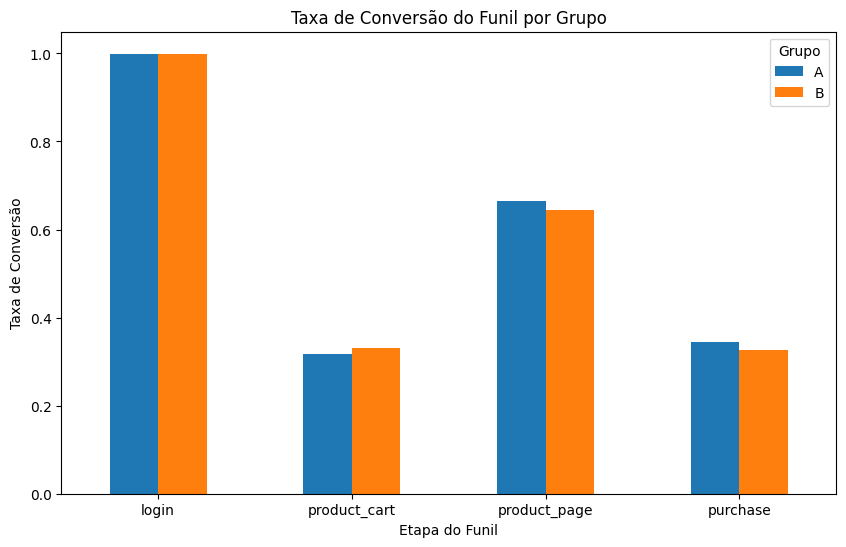

In [49]:
# Criando um gráfico de barras para comparar A e B em cada etapa
funnel_conversion.T.plot(kind='bar', figsize=(10, 6))
plt.title('Taxa de Conversão do Funil por Grupo')
plt.xlabel('Etapa do Funil')
plt.ylabel('Taxa de Conversão')
plt.xticks(rotation=0)
plt.legend(title='Grupo')
plt.show()

O gráfico mostra que as taxas de conversão dos grupos A e B são bastante semelhantes em todas as etapas do funil. No login, ambos os grupos apresentam conversão de 99.97%, ou seja, conversão de quase 100%. Na etapa de product_cart, o grupo B apresenta uma conversão ligeiramente superior (33.15 versus 31.71), enquanto nas etapas de product_page (66.41 versus 64.43) e purchase (34.37 versus 32.63) o grupo A apresenta taxas um pouco maiores. As diferenças, porém, são pequenas, indicando que, visualmente, não há uma diferença expressiva no comportamento dos grupos ao longo do funil. Além disso, notamos que as etapas product_cart e purchase apresentam, nos dois grupos, a maior perda de usuários. O próximo passo será calcular a conversão de uma etapa para a outra. Ademais, a confirmação de que essas diferenças são estatisticamente significativas deve ser feita por meio dos testes estatísticos, ou seja, não é correto concluir apenas pelo gráfico que o novo sistema de recomendação melhorou ou piorou a conversão. O gráfico mostra as diferenças visuais; o teste estatístico é que vai dizer se essas diferenças são significativas.

In [50]:
# Calculando a conversão de cada etapa para a seguinte
funnel_conversion = pd.DataFrame(index=['A', 'B'])

funnel_conversion['login → product_page'] = (funnel['product_page'] / funnel['login'])

funnel_conversion['product_page → product_cart'] = (funnel['product_cart'] / funnel['product_page'])

funnel_conversion['product_cart → purchase'] = (funnel['purchase'] / funnel['product_cart'])

print((funnel_conversion * 100).round(2))

   login → product_page  product_page → product_cart  product_cart → purchase
A                 66.42                        47.75                   108.40
B                 64.46                        51.45                    98.43


In [51]:
# Calculando a diferença percentual do grupo B em relação ao grupo A
increase = ((funnel_conversion.loc['B'] - funnel_conversion.loc['A'])/ funnel_conversion.loc['A']* 100)
print(increase.round(2))

login → product_page          -2.96
product_page → product_cart    7.75
product_cart → purchase       -9.20
dtype: float64


Na análise inicial do funil, o grupo B apresentou uma conversão inferior ao grupo A na etapa login → product_page, com 64.46% contra 66.42%. Já na etapa product_page → product_cart, o grupo B apresentou desempenho superior, com 51.45% contra 47.75% no grupo A, ou seja, apenas 7.75% a mais, não cumprindo o requisito do aumento mínimo de 10% em cada etapa do funil. Na etapa product_cart → purchase, foi observada uma taxa superior a 100% no grupo A, indicando que a simples divisão do número de usuários que realizaram cada evento não representa corretamente uma conversão sequencial, já que não é possível um valor acima de 100%. Portanto, essa etapa deverá ser recalculada considerando a ordem temporal dos eventos de cada usuário antes de qualquer conclusão sobre o desempenho do grupo B.  
Para corrigir product_cart → purchase, precisamos considerar a ordem dos eventos de cada usuário. Não basta contar quantos usuários tiveram product_cart e quantos tiveram purchase.  
A regra será: Um usuário só conta como conversão product_cart → purchase se o product_cart tiver ocorrido antes do purchase.

In [52]:
# Encontrando a primeira ocorrência de cada evento por usuário
first_events = (test_events.groupby(['user_id', 'event_name'])['event_dt'].min().unstack())
print(first_events)

event_name                     login        product_cart        product_page  \
user_id                                                                        
0002CE61FF2C4011 2020-12-07 04:37:36 2020-12-07 04:37:37 2020-12-07 04:37:42   
001064FEAAB631A1 2020-12-20 14:43:27                 NaT 2020-12-20 14:43:28   
0010A1C096941592 2020-12-17 21:07:27                 NaT 2020-12-17 21:07:27   
001E72F50D1C48FA 2020-12-17 15:44:05                 NaT 2020-12-17 15:44:06   
002412F1EB3F6E38 2020-12-09 09:35:20                 NaT 2020-12-09 09:35:20   
...                              ...                 ...                 ...   
FFE5B14BD55C1C5C 2020-12-19 07:11:39 2020-12-19 07:11:40                 NaT   
FFE600EEC4BA7685 2020-12-13 21:43:00 2020-12-13 21:43:01 2020-12-13 21:43:05   
FFE7FC140521F5F6 2020-12-23 09:21:10 2020-12-23 09:21:10 2020-12-23 09:21:10   
FFEFC0E55C1CCD4F 2020-12-13 23:52:22                 NaT                 NaT   
FFF58BC33966EB51 2020-12-13 17:55:19    

In [53]:
# Adicionando ao grupo
first_events = first_events.merge(participants_clean[['user_id', 'group']], on='user_id', how='left')

In [54]:
# Selecionando os usuários que tiveram product_page
page_users = first_events[first_events['product_page'].notna()].copy()

In [55]:
# Selecionando os usuários que tiveram product_cart depois de product_page
page_to_cart = page_users[page_users['product_cart'].notna() & (page_users['product_page'] < page_users['product_cart'])].copy()

In [56]:
# Contando o número de usuários únicos que tiveram product_cart depois de product_page
page_to_cart_count = (page_to_cart.groupby('group')['user_id'].nunique())
print(page_to_cart_count)

group
A    441
B    344
Name: user_id, dtype: int64


In [57]:
# Contando o número de usuários que chegaram em product_page
total_page_users = (page_users.groupby('group')['user_id'].nunique())
print(total_page_users)

group
A    4937
B    3715
Name: user_id, dtype: int64


In [58]:
# Calculando a conversão
page_cart_conversion = (page_to_cart_count / total_page_users)
print((page_cart_conversion * 100).round(2))

group
A    8.93
B    9.26
Name: user_id, dtype: float64


No grupo A, 8.93% dos usuários que acessaram a página de produtos, adicionaram um produto ao carrinho. No grupo B, essa proporção foi de 9.26%. Dessa forma, concluímos que os grupos A e B são também muito parecidos nessa etapa da conversão.

In [59]:
# Calculando o aumento do grupo B em relação ao grupo A
increase_page_cart = ((page_cart_conversion.loc['B'] - page_cart_conversion.loc['A'])/ page_cart_conversion.loc['A']* 100)
print(increase_page_cart.round(2))

3.66


Em product_page → product_cart também não houve o aumento mínimo de 10%, conforme especificado, apresentando um aumento de apenas 3.66% do grupo B em relação ao grupo A.

In [60]:
# Selecionando  os usuários que tiveram product_cart
cart_users = first_events[first_events['product_cart'].notna()].copy()

In [61]:
# Contando o número de usuários únicos que tiveram purchase depois de product_cart 
cart_to_purchase = cart_users[cart_users['purchase'].notna() & (cart_users['product_cart'] < cart_users['purchase'])].copy()

In [62]:
# Contando o número de usuários únicos que tiveram purchase depois de product_cart
purchase_after_cart = (cart_to_purchase.groupby('group')['user_id'].nunique())
print(purchase_after_cart)

group
A    6
B    5
Name: user_id, dtype: int64


In [63]:
# Contando o total de usuários que chegaram em product_cart
total_cart_users = (cart_users.groupby('group')['user_id'].nunique())
print(total_cart_users)

group
A    2357
B    1911
Name: user_id, dtype: int64


In [64]:
# Calculando a conversão
cart_purchase_conversion = (purchase_after_cart / total_cart_users)
print((cart_purchase_conversion * 100).round(2))

group
A    0.25
B    0.26
Name: user_id, dtype: float64


No grupo A, 25% dos usuários que adicionaram um produto ao carrinho posteriormente realizaram uma compra. No grupo B, 26% dos usuários que adicionaram um produto ao carrinho posteriormente realizaram uma compra. Dessa forma, concluímos que os grupos A e B são também muito parecidos nessa etapa da conversão. 

In [65]:
# Calculando o aumento do grupo B em relação ao grupo A
increase_cart_purchase = ((cart_purchase_conversion.loc['B'] - cart_purchase_conversion.loc['A'])/ cart_purchase_conversion.loc['A']* 100)
print(increase_cart_purchase.round(2))

2.78


Em product_cart → purchase também não houve o aumento mínimo de 10%, conforme especificado, apresentando um aumento de apenas 2.78% do grupo B em relação ao grupo A.

In [66]:
# Verificando se o número de eventos por usuário está distribuído de forma equilibrada entre A e B
events_per_user = (test_events_14d.groupby(['group', 'user_id']).size().reset_index(name='event_count'))
print(events_per_user)

      group           user_id  event_count
0         A  0002CE61FF2C4011           12
1         A  001064FEAAB631A1            0
2         A  0010A1C096941592           12
3         A  001E72F50D1C48FA            0
4         A  002412F1EB3F6E38            6
...     ...               ...          ...
26385     B  FFE5B14BD55C1C5C            2
26386     B  FFE600EEC4BA7685            0
26387     B  FFE7FC140521F5F6           16
26388     B  FFEFC0E55C1CCD4F            3
26389     B  FFF58BC33966EB51            3

[26390 rows x 3 columns]


In [67]:
# Imprimindo um resumo estatístico dos grupos A e B
events_per_user.groupby('group')['event_count'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,13195.0,4.130277,4.900983,0.0,0.0,3.0,6.0,40.0
B,13195.0,3.034255,4.387465,0.0,0.0,0.0,6.0,36.0


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Boa verificação de comparabilidade: **13.195 usuários em cada grupo**, mas distribuições de eventos por usuário diferentes.

Ter grupos do mesmo tamanho é apenas a primeira condição. Se os usuários de um lado geram sistematicamente menos eventos, isso já é um sinal (de menor engajamento, ou de coleta incompleta) e precisa entrar na interpretação. O diagrama de caixa ao lado deixa a diferença visível de imediato.
</div>

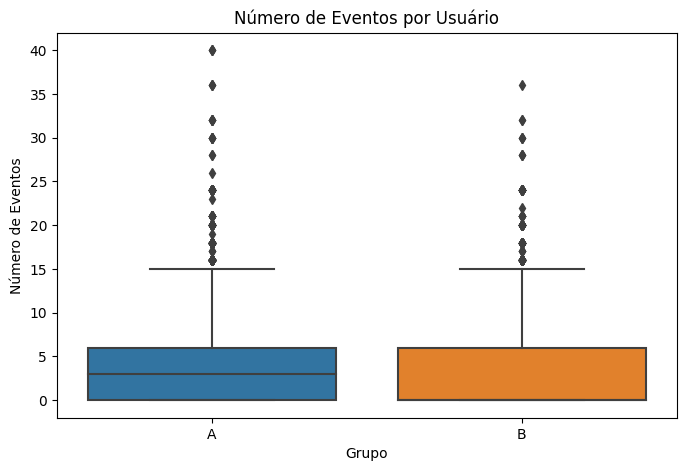

In [68]:
# Construindo um diagrama de caixa para comparar as distribuições dos grupos A e B
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=events_per_user,
    x='group',
    y='event_count'
)

plt.title('Número de Eventos por Usuário')
plt.xlabel('Grupo')
plt.ylabel('Número de Eventos')

plt.show()

Podemos observar que o número de usuários é igual nos dois grupos (13195 em cada), porém a distribuição do número de eventos por usuário apresenta diferenças. O grupo A possui uma média de 4.13 eventos por usuário, enquanto o grupo B possui 3.03. A diferença também aparece na mediana, que é 3 eventos no grupo A e 0 no grupo B. Ademais, o desvio padrão do grupo A é de 4.90, enquanto do grupo B é de 4.39 e o valor máximo no grupo A é de 40 eventos, enquanto que no grupo B é de 36. Portanto, as amostras não apresentam uma distribuição totalmente equilibrada quanto ao número de eventos por usuário, sendo necessário considerar essa diferença na análise do experimento.

In [69]:
# Criando uma coluna com a data do evento
test_events['date'] = test_events['event_dt'].dt.date

In [70]:
# Verificando como os eventos estão distribuídos ao longo dos dias por grupo
events_by_day_group = test_events.groupby(['date', 'group']).size().unstack(fill_value=0)
print(events_by_day_group)

group          A     B
date                  
2020-12-07  1273  1300
2020-12-08  1425  1343
2020-12-09  1478  1443
2020-12-10  1565  1453
2020-12-11  1603  1404
2020-12-12  2127  1821
2020-12-13  2281  2089
2020-12-14  3413  2387
2020-12-15  3156  2217
2020-12-16  2995  2107
2020-12-17  3176  2107
2020-12-18  3313  2124
2020-12-19  3515  2273
2020-12-20  3869  2465
2020-12-21  4794  3191
2020-12-22  3822  2740
2020-12-23  3313  2513
2020-12-24  2608  1880
2020-12-26  1836  1344
2020-12-27  1728  1211
2020-12-28  1456  1101
2020-12-29  1256   925
2020-12-30    12     4


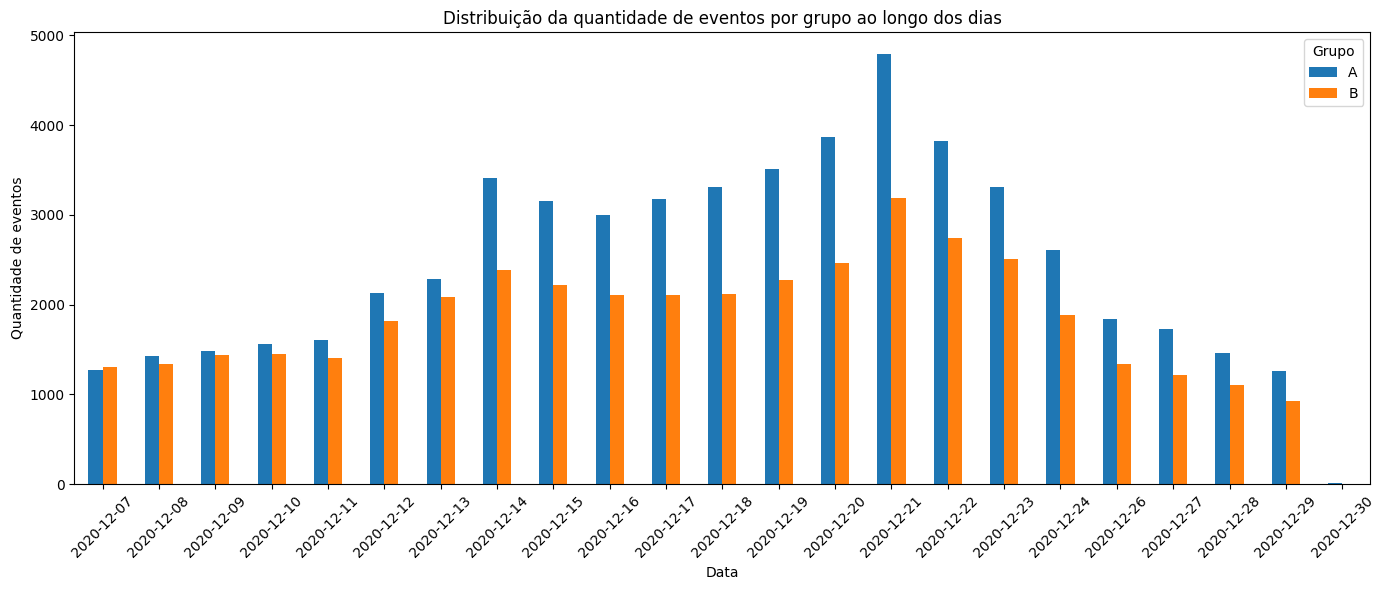

In [71]:
# Criando um gráfico de barras para visualizar como os eventos estão distribuídos ao longo dos dias por grupo
events_by_day_group.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Distribuição da quantidade de eventos por grupo ao longo dos dias')
plt.xlabel('Data')
plt.ylabel('Quantidade de eventos')
plt.xticks(rotation=45)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

A distribuição dos eventos ao longo dos dias mostra que os dois grupos seguiram um comportamento temporal muito semelhante, indicando que ambos foram expostos às mesmas variações de atividade durante o período do experimento. No entanto, o grupo A registrou um volume maior de eventos na maior parte dos dias.

O experimento começou com uma quantidade relativamente baixa de eventos, com 1.273 eventos no grupo A e 1.300 no grupo B em 07/12. Nos dias seguintes, houve um crescimento gradual da atividade em ambos os grupos. Entre 07/12 e 13/12, o grupo A passou de 1.273 para 2.281 eventos (aumento de aproximadamente 79%), enquanto o grupo B passou de 1.300 para 2.089 eventos (crescimento de cerca de 61%).

O período de maior atividade ocorreu entre 14/12 e 22/12. Nesse intervalo, o grupo A manteve diariamente entre 2.995 e 4.794 eventos, enquanto o grupo B registrou entre 2.107 e 3.191 eventos. O pico de atividade foi observado em 21/12, quando o grupo A alcançou 4.794 eventos e o grupo B 3.191 eventos. Nesse dia, o grupo A apresentou cerca de 50% mais eventos do que o grupo B (diferença de 1.603 eventos).

Após o pico, observa-se uma redução gradual no volume de eventos. Em 24/12, os eventos caíram para 2.608 no grupo A e 1.880 no grupo B. A queda continua após o período de Natal, chegando a 1.256 eventos no grupo A e 925 no grupo B em 29/12. No último dia do conjunto de dados (30/12), há apenas 12 eventos no grupo A e 4 no grupo B, um volume extremamente baixo quando comparado aos dias anteriores.

Esse comportamento indica que 30/12 contém dados incompletos ou representa um dia parcialmente coletado, sendo uma peculiaridade importante do conjunto de dados e um possível candidato à exclusão em análises temporais.

No total, ambos os grupos apresentam a mesma tendência de crescimento, pico e queda dos eventos, sugerindo que as diferenças observadas estão relacionadas ao volume de atividade ao longo do período e não a mudanças específicas provocadas pelo experimento. Ainda assim, o maior número de eve ntos no grupo A deve ser considerado nas comparações entre os grupos, sendo recomendável utilizar taxas de conversão ao invés de comparar apenas contagens absolutas de eventos.

Como analisado e discutido nas etapas anteriores, antes de prosseguir para o teste A/B, os principais pontos de atenção eram os 441 usuários presentes nos dois grupos, que foram removidos, a diferença na distribuição de eventos por usuário e eventuais oscilações na quantidade de eventos ao longo dos dias. Após a remoção desses usuários, cada participante passou a pertencer a apenas um grupo, reduzindo o risco de interferência entre as amostras. A diferença na quantidade de eventos por usuário foi identificada e deve ser considerada na interpretação dos resultados, embora os grupos apresentem a mesma quantidade de usuários. Por fim, a distribuição dos eventos ao longo dos dias foi analisada para verificar possíveis períodos atípicos ou diferenças relevantes entre os grupos. Essas verificações permitem prosseguir para a análise estatística do teste A/B com maior segurança, considerando as possíveis limitações identificadas na etapa exploratória.

**5. Testes A/B** — Testes Z para proporções

Como estamos comparando taxas de conversão entre dois grupos, o teste Z para duas proporções é apropriado.
Como o objetivo do teste A/B é verificar se a alteração implementada no grupo B produziu uma diferença na conversão em relação ao grupo A, precisamos comparar as proporções de usuários que realizaram determinada ação em cada grupo. O teste Z para duas proporções é adequado porque permite comparar estatisticamente essas duas proporções e verificar se a diferença observada entre os grupos pode ser atribuída ao acaso ou se há evidências de uma diferença real entre eles. Dessa forma, o teste Z permite avaliar se o comportamento do grupo experimental B é estatisticamente diferente do grupo de controle A.

Para cada etapa:

Grupo A = controle  
Grupo B = teste

A hipótese será:

**H0:** As proporções de conversão dos grupos A e B são iguais.

**H1:** As proporções de conversão dos grupos A e B são diferentes.

alpha = 0.05

In [72]:
# Fazendo o teste Z para product_page → product_cart
from statsmodels.stats.proportion import proportions_ztest

count = [
    page_to_cart_count['A'],
    page_to_cart_count['B']
]

nobs = [
    total_page_users['A'],
    total_page_users['B']
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

print('Teste Z: product_page → product_cart')
print(f'Z = {z_stat:.4f}')
print(f'p-valor = {p_value:.4f}')

alpha = 0.05

if p_value < alpha:
    print('Rejeitamos H0.')
    print('Há diferença estatisticamente significativa entre os grupos A e B.')
else:
    print('Não rejeitamos H0.')
    print('Não há diferença estatisticamente significativa entre os grupos A e B.')

Teste Z: product_page → product_cart
Z = -0.5245
p-valor = 0.5999
Não rejeitamos H0.
Não há diferença estatisticamente significativa entre os grupos A e B.


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Escolha correta de teste: para comparar **proporções** entre dois grupos, o `proportions_ztest` é o instrumento adequado. Um teste t seria inapropriado aqui, porque a variável é binária (converteu ou não).

E você calculou a conversão **de etapa para etapa** (de quem viu a página para quem colocou no carrinho, e de quem colocou no carrinho para quem comprou), que é o que o funil pede, em vez de comparar tudo contra o total.
</div>

In [73]:
# Fazendo o teste Z para product_cart → purchase

count = [
    purchase_after_cart['A'],
    purchase_after_cart['B']
]

nobs = [
    total_cart_users['A'],
    total_cart_users['B']
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

print('Teste Z: product_cart → purchase')
print(f'Z = {z_stat:.4f}')
print(f'p-valor = {p_value:.4f}')

alpha = 0.05

if p_value < alpha:
    print('Rejeitamos H0.')
    print('Há diferença estatisticamente significativa entre os grupos A e B.')
else:
    print('Não rejeitamos H0.')
    print('Não há diferença estatisticamente significativa entre os grupos A e B.')

Teste Z: product_cart → purchase
Z = -0.0454
p-valor = 0.9638
Não rejeitamos H0.
Não há diferença estatisticamente significativa entre os grupos A e B.


Como foram realizados dois testes estatísticos para avaliar as diferentes etapas do funil (product_page → product_cart e product_cart → purchase), é necessário considerar o efeito de múltiplas comparações. A realização de vários testes aumenta a probabilidade de obter um resultado estatisticamente significativo por acaso, elevando o risco de erro do tipo I.

Para controlar esse risco, será aplicada a **correção de Bonferroni**. Considerando que são 2 testes e um nível de significância inicial de 5% (α = 0.05), o nível de significância corrigido será calculado dividindo o alpha de 0.05 por 2.

Dessa forma, nos testes Z corrigidos, será considerado estatisticamente significativo um resultado cujo p-valor seja **inferior a 0.025**.

A hipótese nula (H0) continuará sendo de que não existe diferença estatisticamente significativa entre as taxas de conversão dos grupos A e B, enquanto a hipótese alternativa (H1) considera que existe diferença significativa entre os grupos.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Boa aplicação da correção de **Bonferroni**, e com a justificativa escrita.

O raciocínio é o certo: cada teste carrega um risco de falso positivo, e esse risco se acumula quando se faz vários. Dividir o alfa pelo número de comparações controla o risco do conjunto.

E você **rodou os testes de novo** contra o limiar corrigido, em vez de apenas mencionar a correção. É a diferença entre dizer que a conclusão resiste ao critério mais rigoroso e mostrar que resiste.
</div>

In [74]:
# Fazendo o teste Z com a correção de Bonferroni para product_page → product_cart

count = [
    page_to_cart_count['A'],
    page_to_cart_count['B']
]

nobs = [
    total_page_users['A'],
    total_page_users['B']
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

print('Teste Z: product_page → product_cart')
print(f'Z = {z_stat:.4f}')
print(f'p-valor = {p_value:.4f}')

alpha = 0.05 / 2

if p_value < alpha:
    print('Rejeitamos H0.')
    print('Há diferença estatisticamente significativa entre os grupos A e B.')
else:
    print('Não rejeitamos H0.')
    print('Não há diferença estatisticamente significativa entre os grupos A e B.')

Teste Z: product_page → product_cart
Z = -0.5245
p-valor = 0.5999
Não rejeitamos H0.
Não há diferença estatisticamente significativa entre os grupos A e B.


In [75]:
# Fazendo o teste Z com a correção de Bonferroni para product_cart → purchase

count = [
    purchase_after_cart['A'],
    purchase_after_cart['B']
]

nobs = [
    total_cart_users['A'],
    total_cart_users['B']
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

print('Teste Z: product_cart → purchase')
print(f'Z = {z_stat:.4f}')
print(f'p-valor = {p_value:.4f}')

alpha = 0.05 / 2

if p_value < alpha:
    print('Rejeitamos H0.')
    print('Há diferença estatisticamente significativa entre os grupos A e B.')
else:
    print('Não rejeitamos H0.')
    print('Não há diferença estatisticamente significativa entre os grupos A e B.')

Teste Z: product_cart → purchase
Z = -0.0454
p-valor = 0.9638
Não rejeitamos H0.
Não há diferença estatisticamente significativa entre os grupos A e B.


In [76]:
# Construindo uma tabela para apresentar os resultados
results = pd.DataFrame({
    'Etapa': [
        'product_page → product_cart',
        'product_cart → purchase'
    ],
    'Aumento B vs A (%)': [
        increase_page_cart,
        increase_cart_purchase
    ],
    'Meta (%)': [
        10,
        10
    ],
    'p-valor': [
        0.5999,
        0.9638
    ]
})

results['Atingiu 10%'] = (
    results['Aumento B vs A (%)'] >= 10
)

results['Diferença significativa'] = (
    results['p-valor'] < 0.05
)

results.round(2)

,Etapa,Aumento B vs A (%),Meta (%),p-valor,Atingiu 10%,Diferença significativa
0,product_page → product_cart,3.66,10,0.60,False,False
1,product_cart → purchase,2.78,10,0.96,False,False


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Excelente forma de apresentar o resultado.** A tabela reúne, em uma única leitura: a etapa do funil, o aumento observado do grupo B, a **meta de 10%** e o p-value.

Essa última coluna é a sacada. Ela separa duas perguntas que costumam ser confundidas:

1. a diferença é **estatisticamente significativa**? (o p-value responde)
2. a diferença é **grande o suficiente para o negócio**? (a comparação com a meta responde)

No seu caso as duas respostas são não, e ter as duas colunas lado a lado deixa isso óbvio.
</div>

Para avaliar se as diferenças observadas nas taxas de conversão entre os grupos A (controle) e B (teste) eram estatisticamente significativas, foi aplicado o teste Z para comparação de duas proporções, utilizando um nível de significância de 5% (α = 0.05). A hipótese nula (H₀) considerou que não existe diferença estatisticamente significativa entre as taxas de conversão dos grupos A e B, enquanto a hipótese alternativa (H₁) considerou que existe diferença significativa entre os grupos.

Na etapa **product_page → product_cart**, foi obtido um valor de Z = -0.5245 e p-valor = 0.5999. Como o p-valor é superior a 0.05, não rejeitamos a hipótese nula. Portanto, não há evidências estatísticas suficientes para afirmar que existe diferença significativa entre as taxas de conversão dos grupos A e B nessa etapa do funil.

Na etapa **product_cart → purchase**, o teste apresentou Z = -0.0454 e p-valor = 0.9638. Novamente, como o p-valor é superior a 0.05, não rejeitamos a hipótese nula. Dessa forma, também não foram encontradas evidências estatísticas de diferença significativa entre os grupos A e B nessa etapa.

Como foram realizadas duas comparações estatísticas referentes às diferentes etapas do funil, foi aplicada a correção de Bonferroni para controlar o risco de erro do tipo I decorrente de múltiplos testes. Assim, o nível de significância foi ajustado de α = 0.05 para α = 0.025 (0,05/2 já que foram realizados 2 testes). Mesmo utilizando o nível de significância corrigido, os p-valores obtidos (0.5999 e 0.9638) permaneceram muito superiores ao limite estabelecido, mantendo-se a decisão de não rejeitar a hipótese nula em nenhuma das etapas.

Os resultados mostram, portanto, que o grupo B não apresentou uma melhoria estatisticamente significativa em nenhuma das duas etapas avaliadas. Além disso, quando comparamos o aumento relativo da conversão de B em relação a A com o objetivo estabelecido para o experimento, observamos que o aumento foi inferior aos 10% esperados em ambas as etapas. Na transição product_page → product_cart, o aumento foi de aproximadamente 3.66%, enquanto na transição product_cart → purchase foi de aproximadamente 2.78%.

Assim, os resultados do teste Z não sustentam a hipótese de que a introdução do novo sistema de recomendação tenha produzido uma melhoria significativa nas taxas de conversão. Além de não haver significância estatística nas diferenças observadas, o aumento mínimo de 10% estabelecido como resultado esperado do experimento também não foi alcançado em nenhuma das etapas analisadas.

Portanto, com base nos resultados estatísticos obtidos, não há evidências suficientes para concluir que o novo sistema de recomendação tenha proporcionado uma melhoria relevante no desempenho do funil de conversão em comparação ao grupo de controle.

# 6. Conclusões e Recomendações

**Conclusões da análise exploratória (EDA)**

A análise exploratória permitiu identificar algumas características importantes do experimento antes da avaliação estatística. Inicialmente, foi observada uma distribuição desigual entre os grupos de teste, o que deve ser considerado na interpretação dos resultados. Também foram identificados 441 usuários presentes simultaneamente nos grupos A e B. Como a participação de um mesmo usuário em dois grupos pode comprometer a independência das amostras, esses usuários foram removidos da análise principal.

Na análise do funil, verificou-se que alguns usuários realizaram o evento product_cart antes de product_page. Por esse motivo, a conversão não foi calculada simplesmente pela divisão do número total de eventos entre as etapas. Foi considerada a ordem temporal dos eventos, garantindo que um usuário somente fosse contabilizado na conversão de uma etapa quando tivesse realizado a etapa seguinte posteriormente.

Também foi considerada a janela de até 14 dias após o cadastro, conforme definido no planejamento do experimento. Essa condição é importante porque usuários cadastrados em datas diferentes não tiveram necessariamente o mesmo período de observação. Além disso, o período do experimento inclui datas próximas ao Natal e ao Ano Novo, que podem influenciar o comportamento de navegação e compra dos usuários.

**Resultados do teste A/B**

Para verificar se as diferenças observadas entre os grupos A e B eram estatisticamente significativas, foram realizados testes Z para comparação de proporções nas duas etapas principais do funil. Como foram realizadas duas comparações, foi aplicada a correção de Bonferroni, reduzindo o nível de significância de 0.05 para 0.025.

Na etapa product_page → product_cart, o teste apresentou Z = -0.5245 e p-valor = 0.5999. Como o p-valor é superior ao nível de significância corrigido de 0.025, não rejeitamos a hipótese nula. Portanto, não foram encontradas evidências estatisticamente significativas de diferença entre os grupos A e B nessa etapa.

Na etapa product_cart → purchase, o resultado foi Z = -0.0454 e p-valor = 0.9638. Novamente, o p-valor foi superior a 0.025, portanto não rejeitamos a hipótese nula. Dessa forma, também não foram encontradas evidências de diferença estatisticamente significativa entre os grupos nessa etapa.

Além da significância estatística, foi avaliado o requisito de negócio de aumento mínimo de 10% na conversão do grupo B em relação ao grupo A. Na etapa product_page → product_cart, o aumento observado foi de aproximadamente 3.66%, enquanto na etapa product_cart → purchase foi de aproximadamente 2.78%. Portanto, nenhuma das duas etapas atingiu o aumento mínimo de 10% estabelecido para o experimento.

**Recomendações**

**1. Não recomendar a implementação do novo sistema de recomendação com base nos resultados atuais.** O grupo B não apresentou diferenças estatisticamente significativas em nenhuma das etapas avaliadas e também não atingiu o aumento mínimo de 10% esperado. Portanto, os resultados não fornecem evidências suficientes de que a nova solução tenha melhorado a conversão.

**2. Revisar o desenho experimental e a execução do experimento antes de realizar um novo teste.** A presença de 441 usuários em ambos os grupos e a distribuição desigual dos participantes indicam problemas na composição da amostra. Em um novo experimento, é importante garantir que cada usuário pertença a apenas um grupo e que a distribuição entre controle e teste seja adequada.

**3. Realizar um novo teste A/B com uma amostra mais bem controlada e acompanhamento adequado.** Recomenda-se garantir que os participantes tenham uma janela de observação comparável de até 14 dias e monitorar a distribuição dos usuários ao longo do período. Isso permitirá uma comparação mais confiável entre os grupos.

**4. Investigar o comportamento do funil antes de uma nova implementação.** A ocorrência de usuários que realizaram product_cart antes de product_page mostra que o comportamento observado não segue necessariamente uma sequência linear. Portanto, análises futuras devem continuar considerando a ordem temporal dos eventos para evitar interpretações incorretas das taxas de conversão.

**5. Considerar fatores externos e a sazonalidade em novos experimentos.** O teste foi realizado durante o período de Natal e Ano Novo, uma época que pode apresentar mudanças no comportamento de compra e navegação dos usuários. Esse contexto pode influenciar as taxas de conversão e dificultar a identificação do efeito real do sistema de recomendação. Recomenda-se, portanto, realizar novos testes em períodos mais representativos do comportamento habitual dos usuários ou considerar possíveis efeitos sazonais durante a análise dos resultados.

**Conclusão geral**

De forma geral, a análise não encontrou evidências de que o novo sistema de recomendação tenha produzido uma melhoria significativa no funil de conversão. Embora o grupo B tenha apresentado pequenos aumentos relativos em algumas etapas, esses aumentos foram inferiores aos 10% esperados e não foram estatisticamente significativos após a aplicação da correção de Bonferroni.

Sendo assim, com os dados disponíveis, a recomendação é **não implementar o novo sistema de recomendação como uma melhoria comprovada neste momento**. O mais adequado é revisar o desenho do experimento, corrigir as inconsistências identificadas e realizar um novo teste A/B com uma amostra adequadamente distribuída e condições de acompanhamento mais controladas.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Fechamento bem organizado, separando as conclusões da análise exploratória das conclusões do teste estatístico.

Essa separação importa porque são dois tipos de achado diferentes: a EDA diz o que havia de errado com o **experimento**, e o teste diz o que aconteceu com a **métrica**. Um resultado nulo em um experimento com falhas de desenho merece uma recomendação diferente de um resultado nulo em um experimento limpo, e o seu texto permite que o leitor faça essa distinção. Parabéns pela aprovação!
</div>